# gan on mnist

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train,_),(_,_)=mnist.load_data()

#normalize [-1,1]
x_train=(x_train.astype("float32")-127.5)/127.5
x_train=np.expand_dims(x_train, axis=-1)
print(x_train.shape)

(60000, 28, 28, 1)


In [2]:
#generator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dense, Reshape

def gan():
    model=Sequential()
    model.add(Dense(128, input_dim=100))
    model.add(LeakyReLU())
    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28,28,1)))
    return model

gen=gan()
gen.summary()

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
#build discriminator

from tensorflow.keras.layers import Flatten

def discrim():
    model=Sequential()
    model.add(Flatten(input_shape=(28,28,1)))
    model.add(Dense(128))
    model.add(LeakyReLU())
    model.add(Dense(1,activation='sigmoid'))
    return model

disc=discrim()
disc.summary()

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#compile

disc.compile(optimizer='adam', loss='binary_crossentropy')
disc.trainable=False
gan_model=Sequential([gen,disc])
gan_model.compile(optimizer='adam', loss='binary_crossentropy')
disc.trainable=True

In [5]:
#train

import matplotlib.pyplot as plt
epochs=50
batch_size=128
half_batch=batch_size//2

d_loss=[]
g_loss=[]

for e in range(epochs):
    idx=np.random.randint(0, x_train.shape[0], half_batch)
    real=x_train[idx]
    noise=np.random.normal(0,1,(half_batch, 100))
    fake=gen.predict(noise, verbose=0)
    d_loss_r=disc.train_on_batch(real, np.ones((half_batch,1)))
    d_loss_f=disc.train_on_batch(fake, np.zeros((half_batch,1)))
    d=float(0.5*(d_loss_r+d_loss_f))

    noise=np.random.normal(0,1,(batch_size,100))
    g=float(gan_model.train_on_batch(noise, np.ones((batch_size,1))))

    d_loss.append(d)
    g_loss.append(g)
    print(f"epoch {e+1} | d loss: {d} | g loss: {g}")

epoch 1 | d loss: 1.2839711904525757 | g loss: 0.6111891269683838
epoch 2 | d loss: 0.8919069766998291 | g loss: 0.40895527601242065
epoch 3 | d loss: 0.9945043325424194 | g loss: 0.29827234148979187
epoch 4 | d loss: 1.1803340911865234 | g loss: 0.23173701763153076
epoch 5 | d loss: 1.370931625366211 | g loss: 0.18913483619689941
epoch 6 | d loss: 1.5561294555664062 | g loss: 0.15937447547912598
epoch 7 | d loss: 1.721205711364746 | g loss: 0.1377582550048828
epoch 8 | d loss: 1.8538050651550293 | g loss: 0.1217372715473175
epoch 9 | d loss: 1.9565637111663818 | g loss: 0.1095157340168953
epoch 10 | d loss: 2.032075881958008 | g loss: 0.09992150217294693
epoch 11 | d loss: 2.0832924842834473 | g loss: 0.09289636462926865
epoch 12 | d loss: 2.102123498916626 | g loss: 0.08839621394872665
epoch 13 | d loss: 2.0911216735839844 | g loss: 0.08669907599687576
epoch 14 | d loss: 2.0649313926696777 | g loss: 0.08769740909337997
epoch 15 | d loss: 2.027235507965088 | g loss: 0.0919612497091293

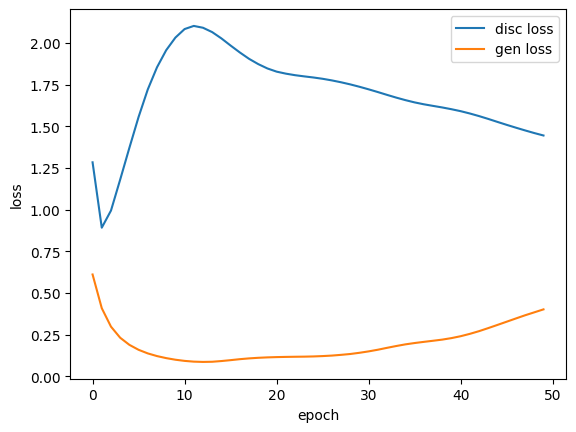

In [6]:
plt.plot(d_loss)
plt.plot(g_loss)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["disc loss", "gen loss"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


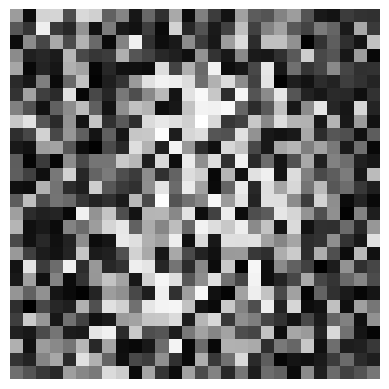

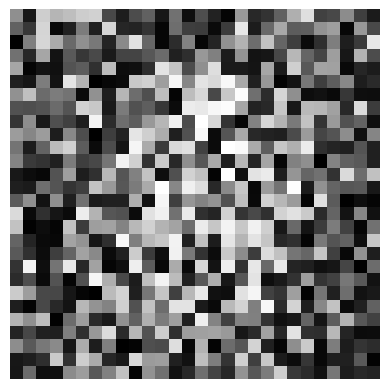

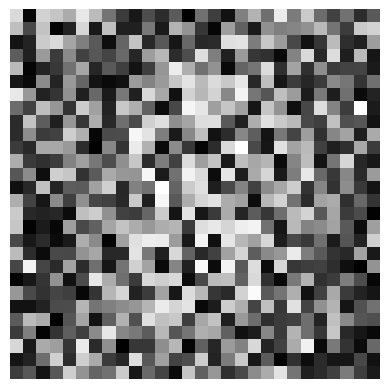

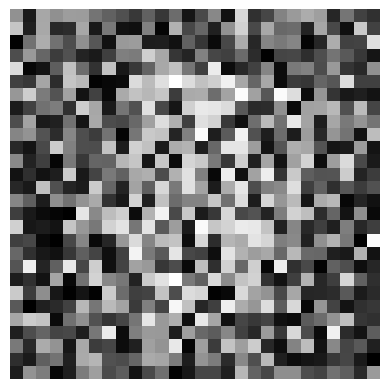

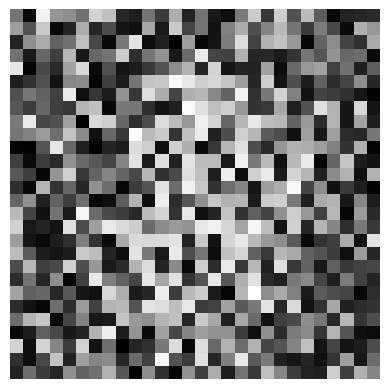

In [7]:
#generate

noise = np.random.normal(0,1,(5,100))
generated_imgs = gen.predict(noise)

# rescale back to [0,1]
generated_imgs = 0.5 * generated_imgs + 0.5

for i in range(5):
    plt.imshow(generated_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.show()